## Оценка качества генерации при уменьшении количества шагов

In [40]:
import torch
from diffusers import DDPMScheduler, UNet2DModel, UNet2DConditionModel
from torch.optim.lr_scheduler import ReduceLROnPlateau
from matplotlib import pyplot as plt
from torch import nn
from torch.utils.data import DataLoader, Subset
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

import warnings
warnings.filterwarnings("ignore")

Using device: cuda


In [2]:
sys.path

['C:\\Users\\PC\\AppData\\Local\\Programs\\Python\\Python312\\python312.zip',
 'C:\\Users\\PC\\AppData\\Local\\Programs\\Python\\Python312\\DLLs',
 'C:\\Users\\PC\\AppData\\Local\\Programs\\Python\\Python312\\Lib',
 'C:\\Users\\PC\\AppData\\Local\\Programs\\Python\\Python312',
 'c:\\Users\\PC\\Desktop\\ML_Projects\\.venv',
 '',
 'c:\\Users\\PC\\Desktop\\ML_Projects\\.venv\\Lib\\site-packages']

In [3]:
sys.path.append(r'C:\Users\PC\Desktop\ML_Projects\Calolib')
from pipeline.metrics import *
from pipeline.physical_metrics.calogan_prd import get_energy_embedding
from pipeline.physical_metrics import calogan_metrics
from pipeline.physical_metrics.prd_score import compute_prd_from_embedding, prd_to_max_f_beta_pair
from pipeline import calodiff
from visualization_aux.visualize_physics import energy_imshow 

In [34]:
new_data = np.load(r"C:\Users\PC\Desktop\ML_Projects\CaloDiff\results_for_comparison with_power_schedule.npz")
images = new_data['images']
labels = new_data['labels']
conditions = new_data['conditions']
images_tensor = torch.tensor(images, dtype=torch.float32)
images_original_scale = torch.expm1(images_tensor)
labels_tensor = torch.tensor(labels)

real_mask = (labels_tensor == 1)
generated_mask = (labels_tensor == 0)

real_images = images_original_scale[real_mask]
generated_images = images_original_scale[generated_mask]
conditions_for_metrics = torch.tensor(conditions[real_mask], dtype=torch.float32)

--- Результаты Физических Метрик ---
PRD Energy AUC: -0.9794
PRD Physics AUC: -0.9714
------------------------------------


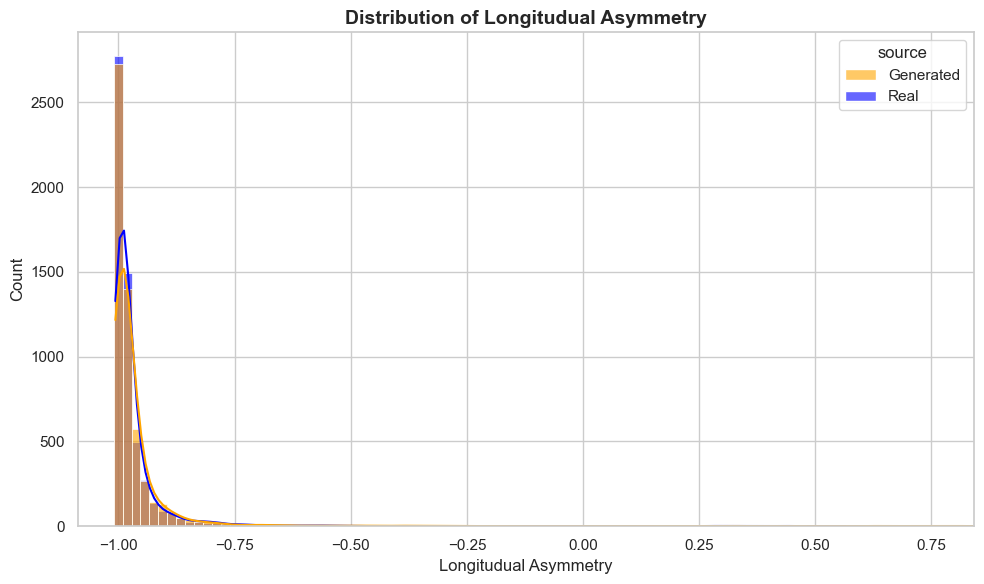

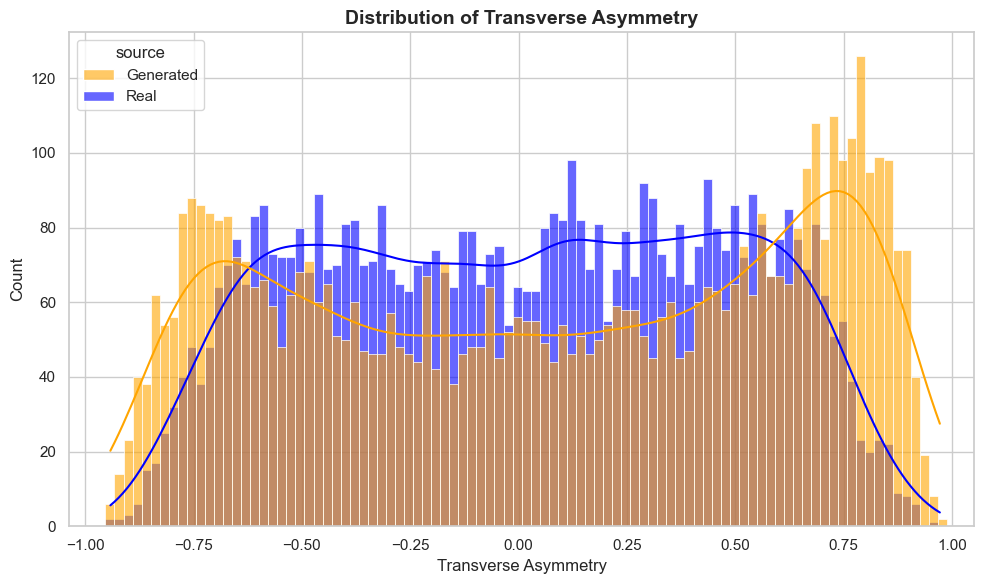

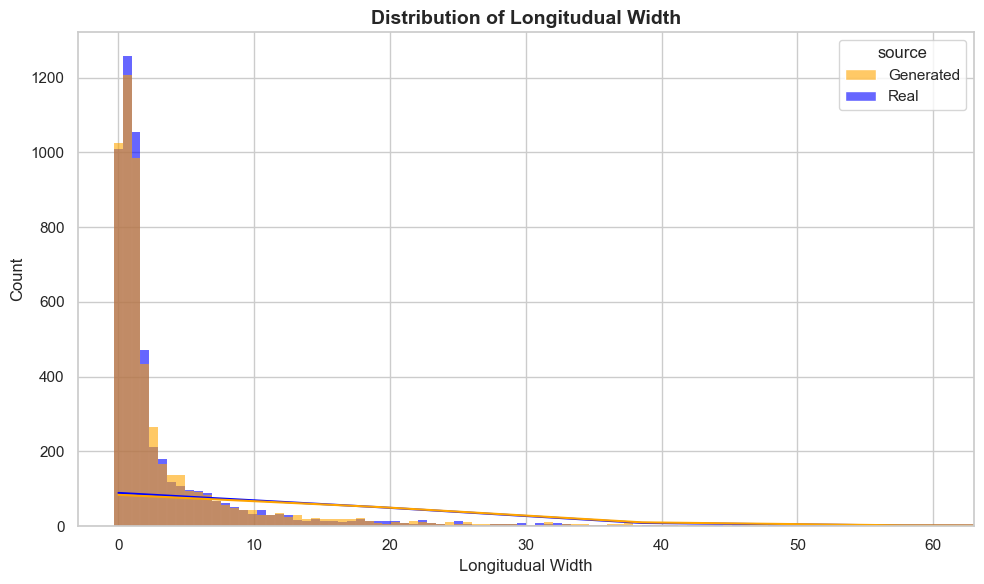

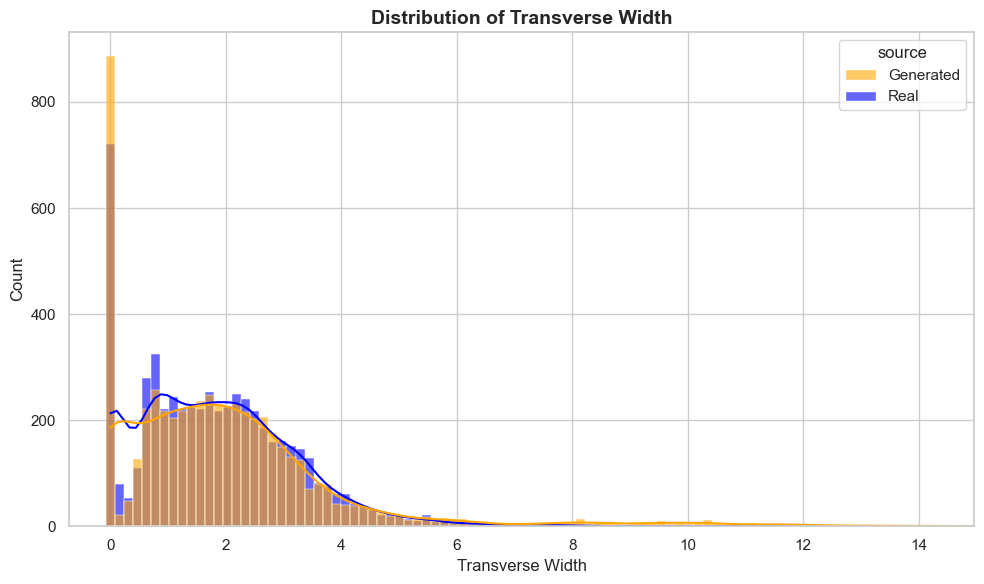

Energy PRD Curve


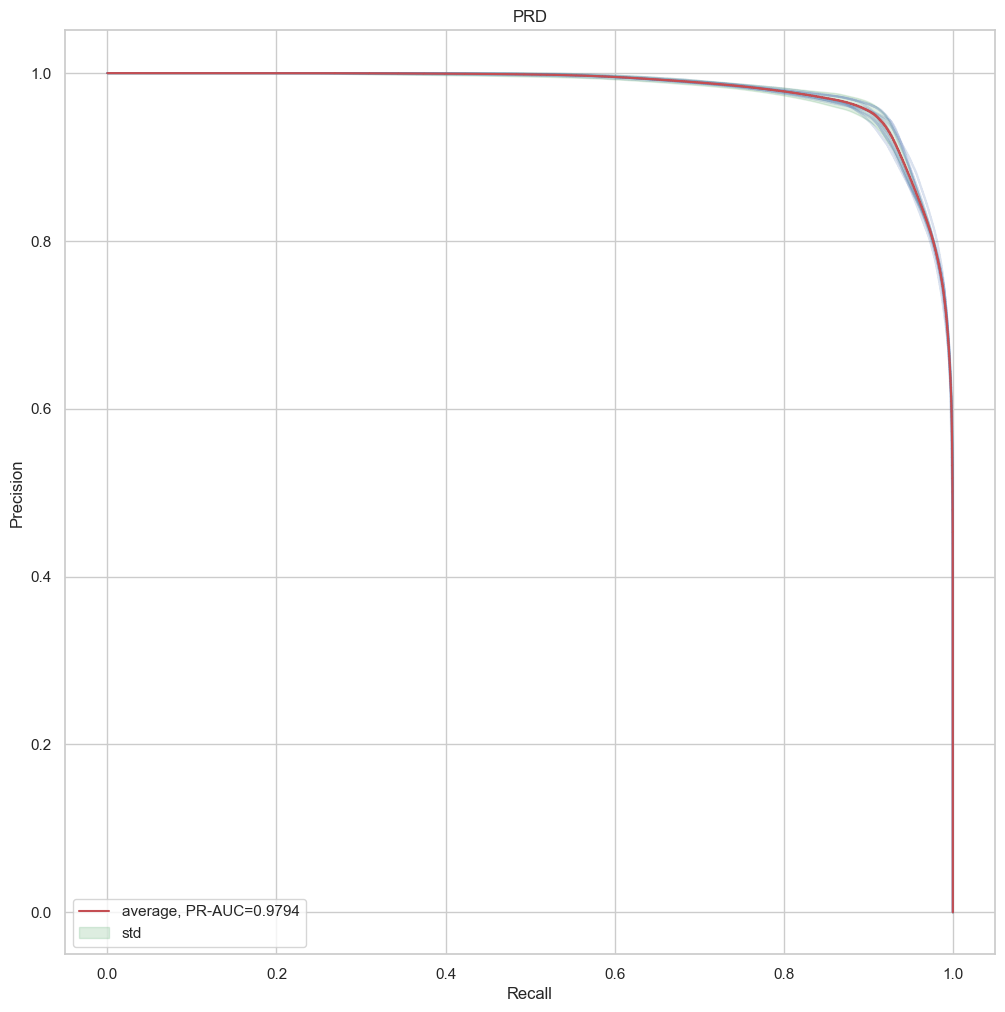

Physics PRD Curve


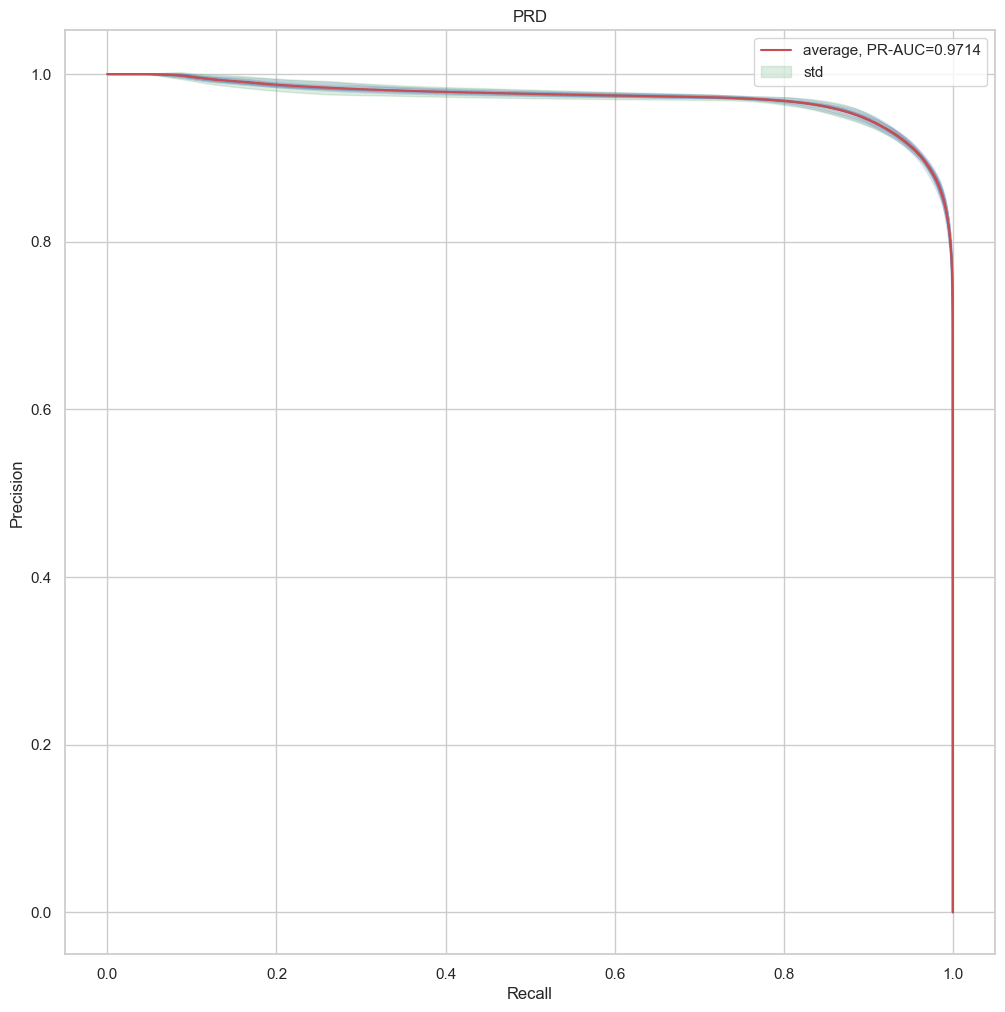

In [ ]:
scores = calodiff.evaluate_and_visualize_physics_metrics(
    gen_images=generated_images,
    real_images=real_images,
    conditions=conditions_for_metrics
)

## Загружаем данные

In [8]:
class PhysicsDataset(torch.utils.data.Dataset):
    """
    one element: (energy deposit, (point, momentum))
    """
    def __init__(self, energy: torch.Tensor, condition: torch.Tensor,
                 transform=None, inverse_transform=None) -> None:
        self.transform = transform
        self.inverse_transform = inverse_transform  # for outer use

        if transform is not None:
            energy = self.transform(energy)

        self.energy = energy
        self.physic_condition = condition

    def __getitem__(self, idx: int) -> tuple:
        return self.energy[idx], self.physic_condition[idx]

    def __len__(self) -> int:
        return self.energy.shape[0]

# принимают batch-и x-ов
def log1p_transform(x: torch.Tensor):
    return torch.log1p(x)


def log1p_inverse_transform(x: torch.Tensor):
    return torch.expm1(x)

def get_physics_dataset(path: str, train: bool = True, val_ratio: float = 0.5,
                        log1p_energy: bool = True) -> torch.utils.data.Dataset:

    """
    Получение данных из файла .npz и формирование датасета для обучения. 
    Данные получаются из файла все, но на обучение идет только импульс и координаты
    """
    TRAIN_VAL_SPLIT_SEED = 0x3df3fa

    data_train = np.load(path)

    np.random.seed(TRAIN_VAL_SPLIT_SEED)
    dataset_size = len(data_train['EnergyDeposit'])
    val_size = int(dataset_size * val_ratio)

    all_indices = np.arange(dataset_size)
    val_indices = np.random.choice(all_indices, size=val_size, replace=False)
    val_mask = np.zeros(dataset_size, dtype=bool)
    val_mask[val_indices] = True
    train_indices = all_indices[~val_mask]
    indices = train_indices if train else val_indices

    energy = torch.tensor(data_train['EnergyDeposit'][indices]).float()
    energy = torch.permute(energy, dims=(0, 3, 1, 2))
    
    momentum = torch.tensor(data_train['ParticleMomentum'][indices]).float()
    momentum_norm = momentum / torch.norm(momentum, dim=1, keepdim=True) # нормировка
    pt = np.sqrt(momentum[:, 0]**2 + momentum[:, 1]**2)
    eta = - np.log(pt/momentum[:, 2])
    phi = np.arctan2(momentum[:, 0], momentum[:, 1])
    momentum_cyl = torch.stack([pt, eta, phi], dim=1) 
    
    total_energy_sci = torch.tensor(data_train['TotalEnergySci'][indices]).float()
    total_energy_sci_min_val = total_energy_sci.min()
    total_energy_sci_max_val = total_energy_sci.max()
    total_energy_sci_norm = (total_energy_sci/total_energy_sci_max_val).unsqueeze(1)  # [0, 1]

    total_energy_absorb = torch.tensor(data_train['TotalEnergyAbsorb'][indices]).float()
    total_energy_absorb_min_val = total_energy_absorb.min()
    total_energy_absorb_max_val = total_energy_absorb.max()
    total_energy_absorb_norm = (total_energy_absorb/total_energy_absorb_max_val).unsqueeze(1)  # [0, 1]

    point = torch.tensor(data_train['ParticlePoint'][indices]).float()
    point_norm = point / torch.norm(point, dim=1, keepdim=True) # нормировка

    
    
    physic_condition = torch.cat([momentum_norm,
                                  momentum_cyl,
                                    point_norm
                                    ], dim=1)  # (N, 8)
    transform, inverse_transform = None, None
    if log1p_energy:
        transform = log1p_transform
        inverse_transform = log1p_inverse_transform

    return PhysicsDataset(energy,
                          physic_condition,
                          transform=transform, inverse_transform=inverse_transform)
data_filepath = r"C:\Users\PC\Desktop\ML_Projects\data\caloGAN_case11_5D_120K.npz"
train_dataset = get_physics_dataset(data_filepath, train=True)
valid_dataset = get_physics_dataset(data_filepath, train=False)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
batch_size = 8
num_batches = 700
num_samples = batch_size * num_batches 
valid_subset = Subset(valid_dataset, indices=range(min(num_samples, len(valid_dataset))))
valid_loader = DataLoader(valid_subset, batch_size=batch_size, shuffle=True)

## Посчитаем метрики при разных значениях расписания

Загружаем модель

In [7]:
class ConditionedUNet(nn.Module):
    def __init__(self, image_size=30, cond_emb_size=9, cross_attention_dim=128):
        """
        A UNet model conditioned via cross-attention.

        Args:
            image_size (int): The size of the input image (e.g., 30 for 30x30).
            cond_emb_size (int): The dimension of the input condition vector.
            cross_attention_dim (int): The dimension for the cross-attention projection.
                                       This is a key hyperparameter.
        """
        super().__init__()

        self.image_size = image_size
        self.cond_emb_size = cond_emb_size
        self.internal_size = image_size + 2 
        self.cond_projection = nn.Linear(cond_emb_size, cross_attention_dim)
        self.model = UNet2DConditionModel(
            sample_size=self.internal_size,
            in_channels=1,  
            out_channels=1,
            layers_per_block=2,
            block_out_channels=(32, 64, 128),
            down_block_types=("DownBlock2D", "AttnDownBlock2D", "AttnDownBlock2D"),
            up_block_types=("AttnUpBlock2D", "AttnUpBlock2D", "UpBlock2D"),
            cross_attention_dim=cross_attention_dim,  
        )

        
    def forward(self, x, t, condition):
        """
        Forward pass for the conditioned UNet.

        Args:
            x (torch.Tensor): The input noisy image, shape [bs, 1, 30, 30]
            t (torch.Tensor): The timestep for the diffusion process.
            condition (torch.Tensor): The condition vector, shape [bs, 9]

        Returns:
            torch.Tensor: The predicted noise, shape [bs, 1, 30, 30]
        """
        bs = x.shape[0]
        padded_x = torch.nn.functional.pad(x, (1, 1, 1, 1)) # [bs, 1, 32, 32]
        condition_emb = self.cond_projection(condition)
        condition_emb = condition_emb.view(bs, 1, -1)
        predicted_noise = self.model(
            sample=padded_x,
            timestep=t,
            encoder_hidden_states=condition_emb
        ).sample 
        return predicted_noise[:, :, 1:-1, 1:-1]
model = ConditionedUNet().to(device)
checkpoint = torch.load(r"C:\Users\PC\Desktop\ML_Projects\data\best_model_on_train_rmsprop.pth", weights_only=True)
model.load_state_dict(checkpoint)

<All keys matched successfully>

In [ ]:
def get_power_schedule(n_total_steps, n_inference_steps, power):
    """
    Генерирует список шагов по степенному закону.
    
    n_total_steps: всего шагов обучения (например, 100)
    n_inference_steps: сколько раз хотим вызвать модель (например, 10)
    power: степень. 
           1.0 = равномерно. 
           >1.0 = гуще около 0 (уточнение деталей).
           <1.0 = гуще около T (работа с структурой шума).
    """
    x = np.linspace(0, 1, n_inference_steps + 1)
    
    y = x ** power
    indices = (y * (n_total_steps - 1)).astype(int)
    
    steps = sorted(list(set(indices)), reverse=True)
    
    if 0 not in steps:
        steps[-1] = 0
        
    return steps

In [ ]:
powers_to_test = [0.4, 0.6, 0.8, 1.0, 1.5, 2.0, 3.0] 
n_total = 100
n_infer = 9 # Хотим ~10 вызовов модели 


In [32]:
new_data_distilled = np.load(r"C:\Users\PC\Desktop\ML_Projects\CaloDiff\results_power_1.5.npz")
images = new_data_distilled['images']
labels = new_data_distilled['labels']
conditions = new_data_distilled['conditions']
images_tensor_distilled = torch.tensor(images, dtype=torch.float32)
images_original_scale = torch.expm1(images_tensor_distilled)
labels_tensor_distilled = torch.tensor(labels)

real_mask = (labels_tensor_distilled == 1)
generated_mask = (labels_tensor_distilled == 0)

real_images_distilled = images_original_scale[real_mask]
generated_images_distilled = images_original_scale[generated_mask]
conditions_for_metrics_distilled = torch.tensor(conditions[real_mask], dtype=torch.float32)

In [37]:
metrics_distilled = calodiff._calculate_physics_metrics(
    generated_images_distilled.cpu().numpy(),
    real_images_distilled.cpu().numpy(),
    conditions_for_metrics_distilled.cpu().numpy()
)

In [38]:
metrics = calodiff._calculate_physics_metrics(
    generated_images.cpu().numpy(),
    real_images.cpu().numpy(),
    conditions_for_metrics.cpu().numpy()
)

In [ ]:
## МатСтат Анализ

def calc_cohens_d(x, y):
    """Вычисляет размер эффекта (Cohen's d)."""
    nx, ny = len(x), len(y)
    dof = nx + ny - 2
    # Объединенная дисперсия
    pool_std = np.sqrt(((nx - 1) * np.var(x, ddof=1) + (ny - 1) * np.var(y, ddof=1)) / dof)
    return (np.mean(x) - np.mean(y)) / pool_std

def analyze_distributions(metrics, metrics_distilled, keys_to_analyze):
    """
    Проводит комплексный анализ двух наборов распределений.
    """
    for key in keys_to_analyze:
        base_data = metrics[key]
        dist_data = metrics_distilled[key]
        ks_stat, p_value = stats.ks_2samp(base_data, dist_data)
        w_dist = stats.wasserstein_distance(base_data, dist_data)
        
        d_stat = calc_cohens_d(base_data, dist_data)
        
        # Относительная ошибка средних и стандартных отклонений (опционально, но полезно)
        mean_diff_pct = abs(np.mean(base_data) - np.mean(dist_data)) / abs(np.mean(base_data) + 1e-9) * 100
        std_diff_pct = abs(np.std(base_data) - np.std(dist_data)) / abs(np.std(base_data) + 1e-9) * 100

        print(f"\n{'='*10} Анализ метрики: {key} {'='*10}")
        print(f"K-S Test D-statistic : {ks_stat:.4f} (p-value: {p_value:.4e})")
        print(f"Wasserstein Dist (W1): {w_dist:.4f}")
        print(f"Cohen's d            : {d_stat:.4f}")
        print(f"Mean Difference      : {mean_diff_pct:.2f}%")
        print(f"Std Difference       : {std_diff_pct:.2f}%")

        sns.set_theme(style="whitegrid")
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle(f"Distribution Analysis: {key}", fontsize=16, fontweight='bold', y=1.05)

        sns.histplot(base_data, color="royalblue", label="Base Mode", kde=True, stat="density", alpha=0.4, ax=axes[0])
        sns.histplot(dist_data, color="darkorange", label="Distilled Model", kde=True, stat="density", alpha=0.4, ax=axes[0])
        axes[0].set_title("Probability Density (KDE)")
        axes[0].set_xlabel("Value")
        axes[0].set_ylabel("Density")
        axes[0].legend()

        sns.ecdfplot(base_data, color="royalblue", label="Base Model", ax=axes[1])
        sns.ecdfplot(dist_data, color="darkorange", label="Distilled Model", linestyle="--", ax=axes[1])
        axes[1].set_title("Empirical CDF")
        axes[1].set_xlabel("Value")
        axes[1].set_ylabel("Cumulative Probability")
        axes[1].legend()

        quantiles = np.linspace(0, 1, 100)
        q_base = np.quantile(base_data, quantiles)
        q_dist = np.quantile(dist_data, quantiles)
        
        axes[2].scatter(q_base, q_dist, color="seagreen", s=15, alpha=0.8)
        
        min_val = min(np.min(base_data), np.min(dist_data))
        max_val = max(np.max(base_data), np.max(dist_data))
        axes[2].plot([min_val, max_val], [min_val, max_val], 'k--', lw=1.5, label='y = x')
        
        axes[2].set_title("Q-Q Plot (Quantile Comparison)")
        axes[2].set_xlabel("Base Quantiles")
        axes[2].set_ylabel("Distilled Quantiles")
        axes[2].legend()

        plt.tight_layout()
        plt.show()


========== Анализ метрики: Gen Longitudual Asymmetry ==========
K-S Test D-statistic : 0.0902 (p-value: 3.1482e-20)
Wasserstein Dist (W1): 0.0079
Cohen's d            : 0.0615
Mean Difference      : 0.75%
Std Difference       : 5.34%


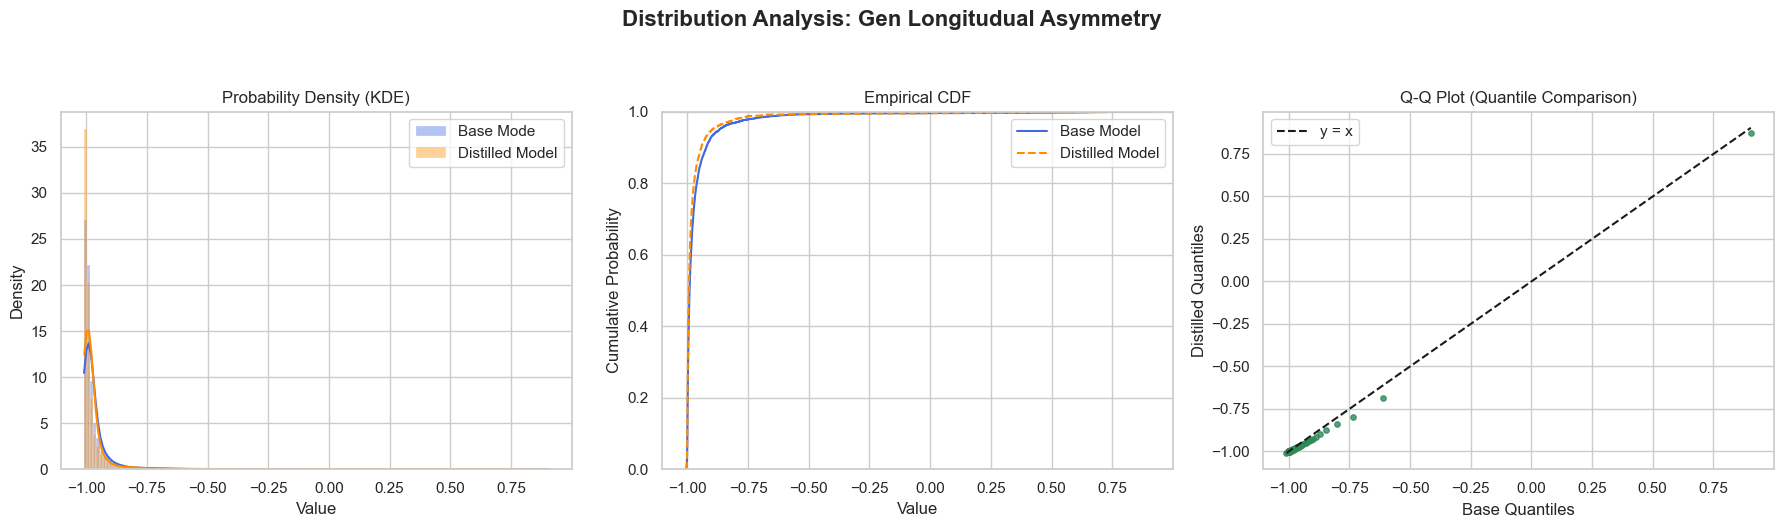


========== Анализ метрики: Gen Transverse Asymmetry ==========
K-S Test D-statistic : 0.0248 (p-value: 6.3475e-02)
Wasserstein Dist (W1): 0.0143
Cohen's d            : 0.0072
Mean Difference      : 6.09%
Std Difference       : 2.00%


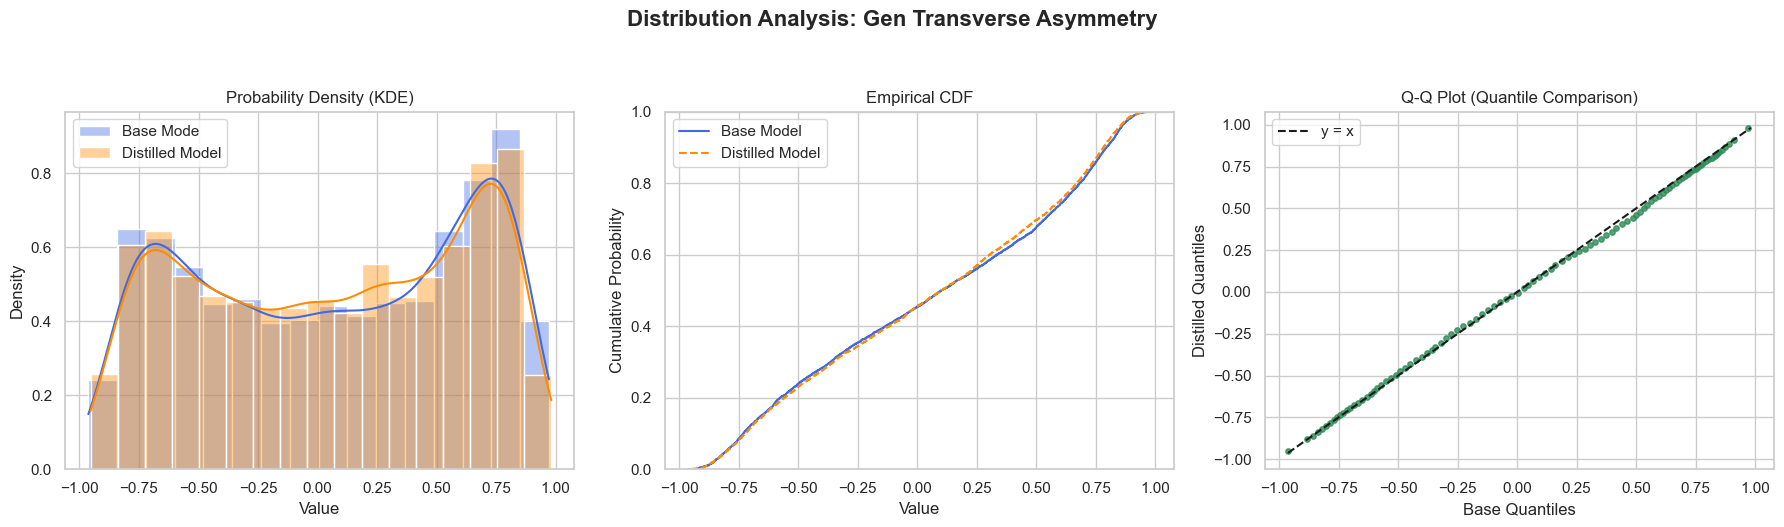


========== Анализ метрики: Gen Longitudual Width ==========
K-S Test D-statistic : 0.0318 (p-value: 6.9769e-03)
Wasserstein Dist (W1): 1.4002
Cohen's d            : -0.0021
Mean Difference      : 1.84%
Std Difference       : 18.90%


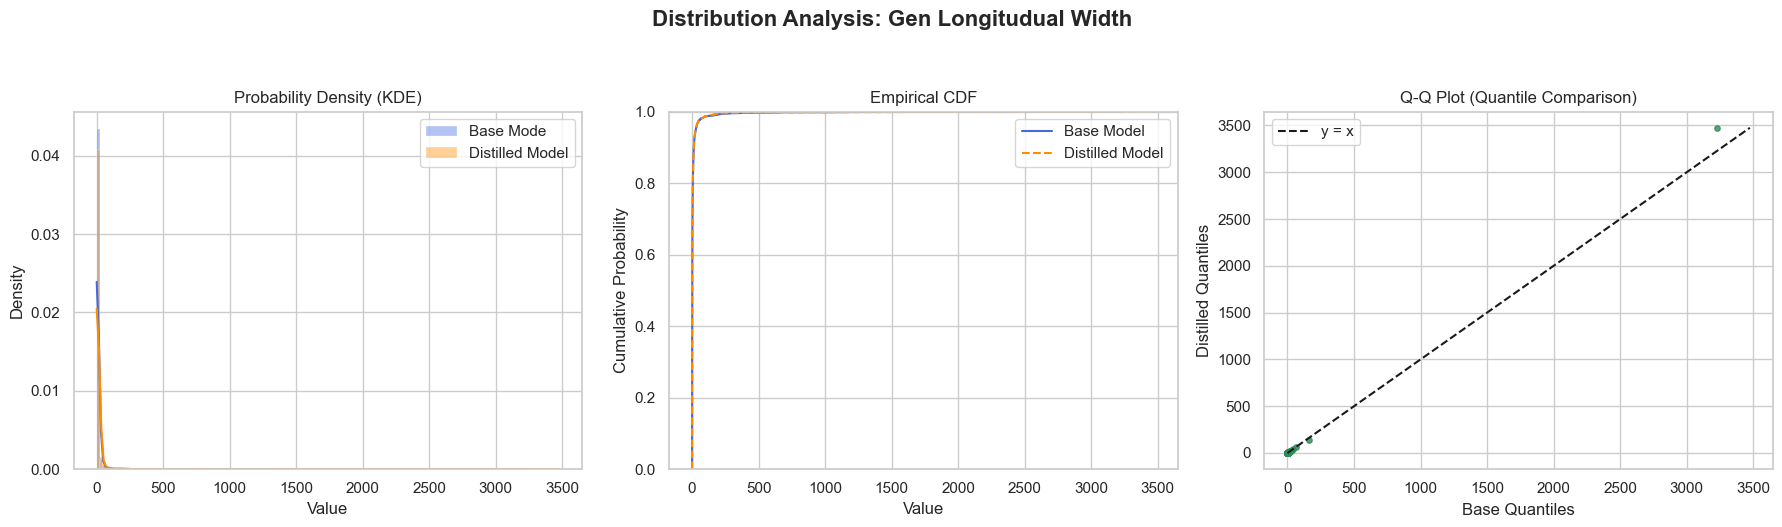


========== Анализ метрики: Gen Transverse Width ==========
K-S Test D-statistic : 0.0434 (p-value: 5.2553e-05)
Wasserstein Dist (W1): 0.1568
Cohen's d            : 0.0596
Mean Difference      : 6.30%
Std Difference       : 3.65%


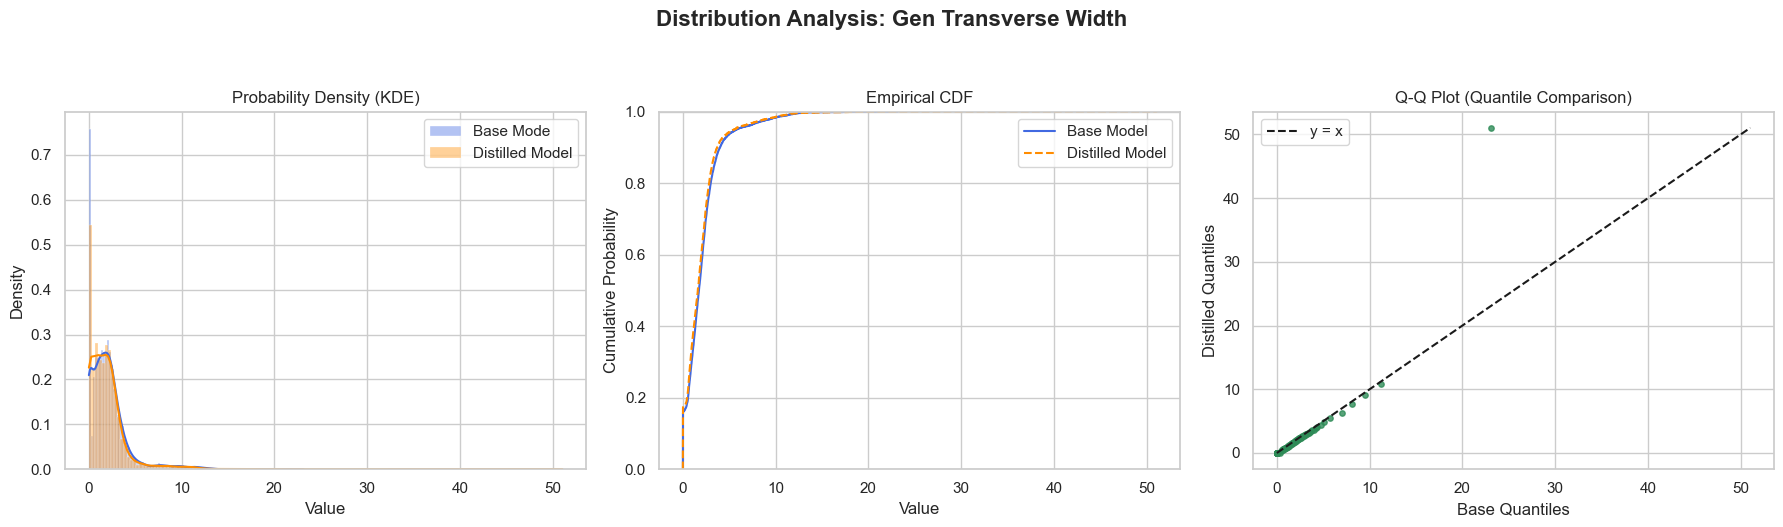

In [42]:
keys_to_analyze = [
    "Gen Longitudual Asymmetry", 
    "Gen Transverse Asymmetry", 
    "Gen Longitudual Width", 
    "Gen Transverse Width"
]
analyze_distributions(metrics, metrics_distilled, keys_to_analyze)

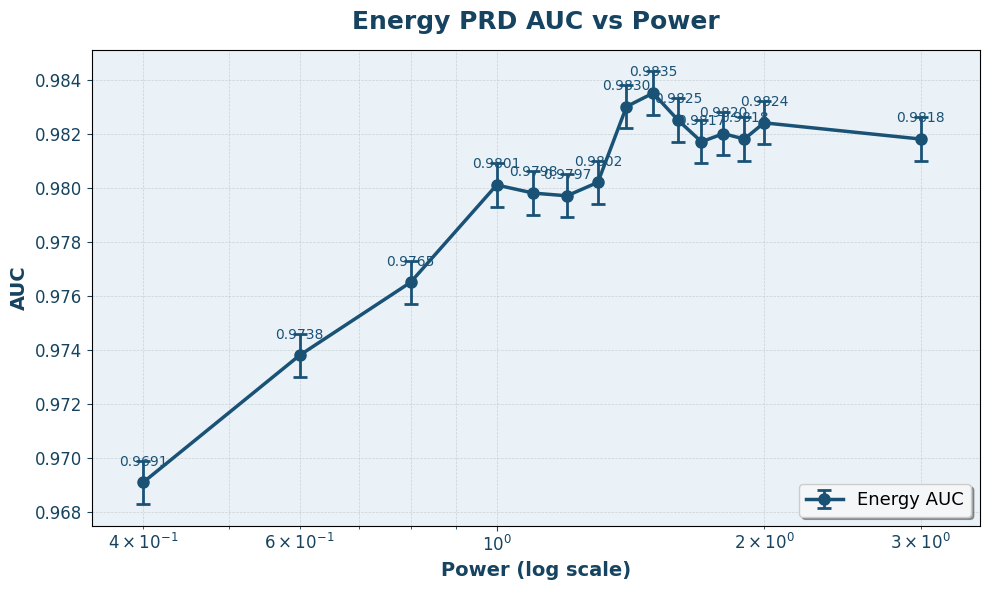

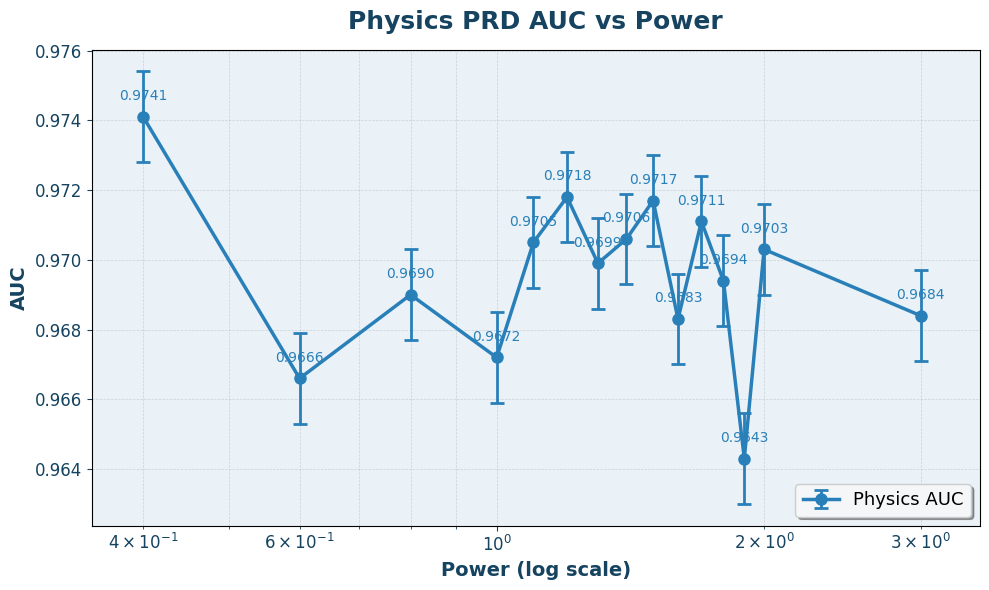

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Восстанавливаем данные с учетом всех точек на графике (15 точек)
powers = [0.4, 0.6, 0.8, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 3.0]

energy_auc = [0.9691, 0.9738, 0.9765, 0.9801, 0.9798, 0.9797, 0.9802, 
              0.9830, 0.9835, 0.9825, 0.9817, 0.9820, 0.9818, 0.9824, 0.9818]


physics_auc = [0.9741, 0.9666, 0.9690, 0.9672, 0.9705, 0.9718, 0.9699, 
               0.9706, 0.9717, 0.9683, 0.9711, 0.9694, 0.9643, 0.9703, 0.9684]

# Приближенные значения стандартного отклонения (чтобы планки погрешностей выглядели гармонично)
energy_std = [0.0008]*15 
physics_std = [0.0013]*15

df = pd.DataFrame({
    'Power': powers,
    'Energy_AUC': energy_auc,
    'Physics_AUC': physics_auc,
    'Energy_AUC_std': energy_std,
    'Physics_AUC_std': physics_std
})

# Задаем красивую синюю палитру из вашего шаблона
color_energy = '#1A5276'  # Темно-синий
color_physics = '#2980B9' # Средне-синий
color_bg = '#EAF2F8'      # Очень светлый синий для фона

# ==========================================
# ГРАФИК 1: ENERGY PRD AUC
# ==========================================
fig1, ax1 = plt.subplots(figsize=(10, 6))
ax1.set_facecolor(color_bg)

# Логарифмическая шкала и обновленные лимиты под Power
ax1.set_xscale('log')
ax1.set_xlim(left=0.35, right=3.5) 
ax1.grid(True, which='both', linestyle='--', linewidth=0.5, color='#BDC3C7', alpha=0.7)

# Рисуем линию с планками погрешностей
ax1.errorbar(df['Power'], df['Energy_AUC'], yerr=df['Energy_AUC_std'], 
            fmt='-o', color=color_energy, label='Energy AUC', 
            capsize=5, capthick=2, elinewidth=2, markersize=8, linewidth=2.5)

# Заголовки и подписи
ax1.set_title('Energy PRD AUC vs Power', fontsize=18, fontweight='bold', color='#154360', pad=15)
ax1.set_xlabel('Power (log scale)', fontsize=14, fontweight='bold', color='#154360')
ax1.set_ylabel('AUC', fontsize=14, fontweight='bold', color='#154360')
ax1.tick_params(axis='both', which='both', labelsize=12, colors='#154360')

# Подписи значений над точками (с немного увеличенным шрифтом)
for i, row in df.iterrows():
    ax1.annotate(f"{row['Energy_AUC']:.4f}", 
                (row['Power'], row['Energy_AUC']),
                textcoords="offset points", 
                xytext=(0, 12), # Смещение вверх
                ha='center', fontsize=10, color=color_energy)

legend1 = ax1.legend(fontsize=13, loc='lower right', frameon=True, fancybox=True, shadow=True)
legend1.get_frame().set_facecolor('#F4F6F7')
fig1.tight_layout()


# ==========================================
# ГРАФИК 2: PHYSICS PRD AUC
# ==========================================
fig2, ax2 = plt.subplots(figsize=(10, 6))
ax2.set_facecolor(color_bg)

# Логарифмическая шкала и обновленные лимиты
ax2.set_xscale('log')
ax2.set_xlim(left=0.35, right=3.5)
ax2.grid(True, which='both', linestyle='--', linewidth=0.5, color='#BDC3C7', alpha=0.7)

# Рисуем линию с планками погрешностей
ax2.errorbar(df['Power'], df['Physics_AUC'], yerr=df['Physics_AUC_std'], 
            fmt='-o', color=color_physics, label='Physics AUC', 
            capsize=5, capthick=2, elinewidth=2, markersize=8, linewidth=2.5)

# Заголовки и подписи
ax2.set_title('Physics PRD AUC vs Power', fontsize=18, fontweight='bold', color='#154360', pad=15)
ax2.set_xlabel('Power (log scale)', fontsize=14, fontweight='bold', color='#154360')
ax2.set_ylabel('AUC', fontsize=14, fontweight='bold', color='#154360')
ax2.tick_params(axis='both', which='both', labelsize=12, colors='#154360')

# Подписи значений над точками
for i, row in df.iterrows():
    ax2.annotate(f"{row['Physics_AUC']:.4f}", 
                (row['Power'], row['Physics_AUC']),
                textcoords="offset points", 
                xytext=(0, 12), 
                ha='center', fontsize=10, color=color_physics)

legend2 = ax2.legend(fontsize=13, loc='lower right', frameon=True, fancybox=True, shadow=True)
legend2.get_frame().set_facecolor('#F4F6F7')
fig2.tight_layout()

plt.show()

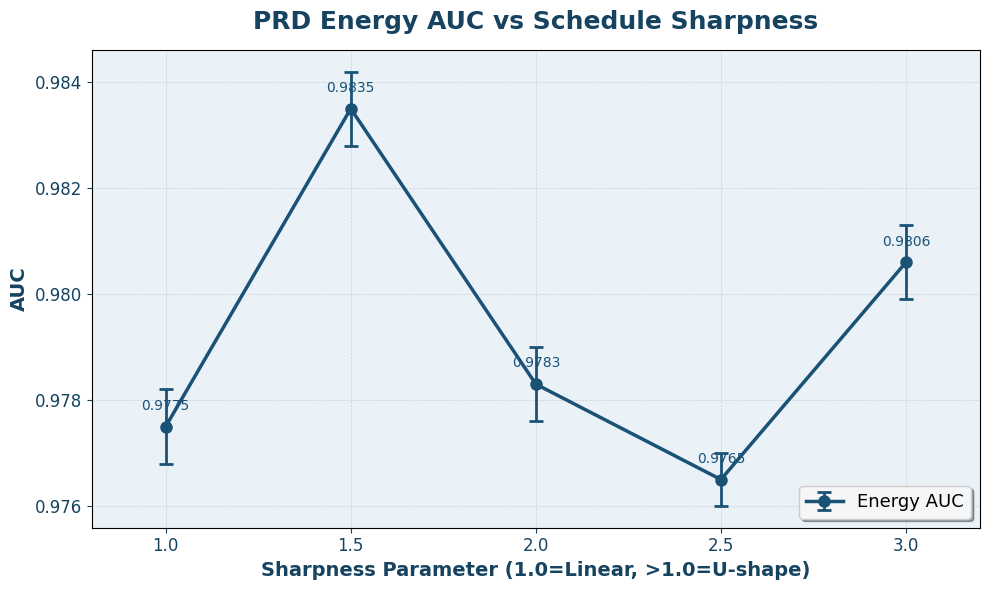

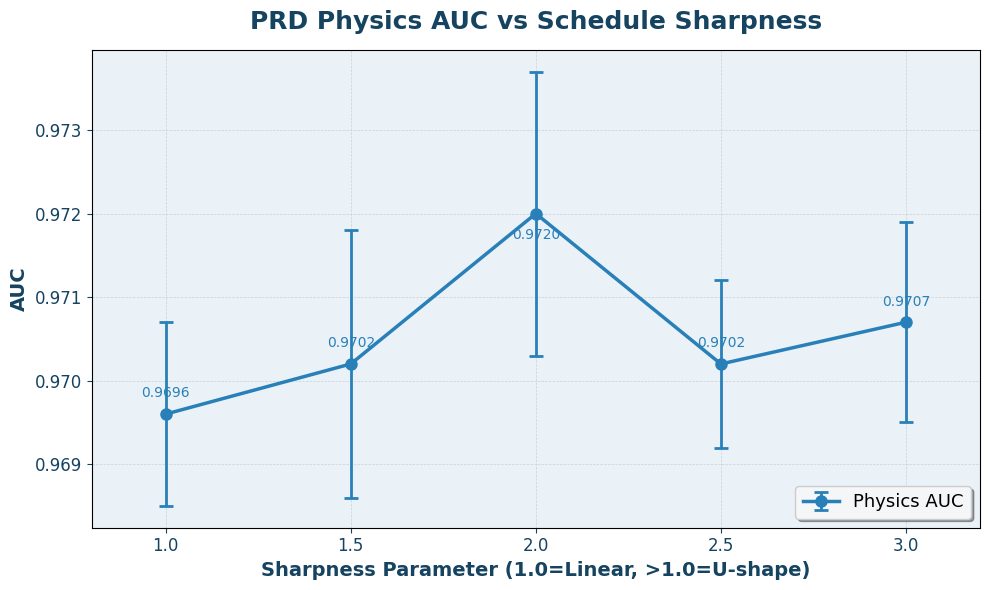

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Данные, считанные с графиков
sharpness = [1.0, 1.5, 2.0, 2.5, 3.0]

energy_auc = [0.9775, 0.9835, 0.9783, 0.9765, 0.9806]
energy_std = [0.0007, 0.0007, 0.0007, 0.0005, 0.0007]

physics_auc = [0.9696, 0.9702, 0.9720, 0.9702, 0.9707]
physics_std = [0.0011, 0.0016, 0.0017, 0.0010, 0.0012]

df = pd.DataFrame({
    'Sharpness': sharpness,
    'Energy_AUC': energy_auc,
    'Energy_AUC_std': energy_std,
    'Physics_AUC': physics_auc,
    'Physics_AUC_std': physics_std
})

# Цветовая палитра
color_energy = '#1A5276'  # Темно-синий
color_physics = '#2980B9' # Средне-синий
color_bg = '#EAF2F8'      # Очень светлый синий для фона

# ==========================================
# ГРАФИК 1: ENERGY PRD AUC
# ==========================================
fig1, ax1 = plt.subplots(figsize=(10, 6))
ax1.set_facecolor(color_bg)

# Линейная шкала и сетка
ax1.set_xlim(left=0.8, right=3.2) 
ax1.grid(True, which='major', linestyle='--', linewidth=0.5, color='#BDC3C7', alpha=0.7)

# Линия с планками погрешностей
ax1.errorbar(df['Sharpness'], df['Energy_AUC'], yerr=df['Energy_AUC_std'], 
            fmt='-o', color=color_energy, label='Energy AUC', 
            capsize=5, capthick=2, elinewidth=2, markersize=8, linewidth=2.5)

# Заголовки и подписи
ax1.set_title('PRD Energy AUC vs Schedule Sharpness', fontsize=18, fontweight='bold', color='#154360', pad=15)
ax1.set_xlabel('Sharpness Parameter (1.0=Linear, >1.0=U-shape)', fontsize=14, fontweight='bold', color='#154360')
ax1.set_ylabel('AUC', fontsize=14, fontweight='bold', color='#154360')
ax1.tick_params(axis='both', which='major', labelsize=12, colors='#154360')

# Подписи значений над точками
for i, row in df.iterrows():
    ax1.annotate(f"{row['Energy_AUC']:.4f}", 
                (row['Sharpness'], row['Energy_AUC']),
                textcoords="offset points", 
                xytext=(0, 12),
                ha='center', fontsize=10, color=color_energy)

legend1 = ax1.legend(fontsize=13, loc='lower right', frameon=True, fancybox=True, shadow=True)
legend1.get_frame().set_facecolor('#F4F6F7')
fig1.tight_layout()
# fig1.savefig('energy_auc_sharpness.png', dpi=300)


# ==========================================
# ГРАФИК 2: PHYSICS PRD AUC
# ==========================================
fig2, ax2 = plt.subplots(figsize=(10, 6))
ax2.set_facecolor(color_bg)

# Линейная шкала и сетка
ax2.set_xlim(left=0.8, right=3.2)
ax2.grid(True, which='major', linestyle='--', linewidth=0.5, color='#BDC3C7', alpha=0.7)

# Линия с планками погрешностей
ax2.errorbar(df['Sharpness'], df['Physics_AUC'], yerr=df['Physics_AUC_std'], 
            fmt='-o', color=color_physics, label='Physics AUC', 
            capsize=5, capthick=2, elinewidth=2, markersize=8, linewidth=2.5)

# Заголовки и подписи
ax2.set_title('PRD Physics AUC vs Schedule Sharpness', fontsize=18, fontweight='bold', color='#154360', pad=15)
ax2.set_xlabel('Sharpness Parameter (1.0=Linear, >1.0=U-shape)', fontsize=14, fontweight='bold', color='#154360')
ax2.set_ylabel('AUC', fontsize=14, fontweight='bold', color='#154360')
ax2.tick_params(axis='both', which='major', labelsize=12, colors='#154360')

# Подписи значений над точками
for i, row in df.iterrows():
    # Для точки 2.0 опустим надпись вниз, чтобы не пересекалась с верхней планкой
    offset = -18 if row['Sharpness'] == 2.0 else 12
    ax2.annotate(f"{row['Physics_AUC']:.4f}", 
                (row['Sharpness'], row['Physics_AUC']),
                textcoords="offset points", 
                xytext=(0, offset), 
                ha='center', fontsize=10, color=color_physics)

legend2 = ax2.legend(fontsize=13, loc='lower right', frameon=True, fancybox=True, shadow=True)
legend2.get_frame().set_facecolor('#F4F6F7')
fig2.tight_layout()
# fig2.savefig('physics_auc_sharpness.png', dpi=300)

plt.show()